<a href="https://colab.research.google.com/github/ReiLamaj1/ClassWork_UPT_CV_2026/blob/main/module3_regional_attributes_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Regional Attributes**
These are measurable properties that describe a specific segmented region of an image rather than individual pixels.After an image is segmented each region can be described using numerical characteristics.Below we are going to mention some of attributes.


1.   Shape-based attributes:These describe the geometry of the region.For example area,peremeter,solidity etc.
2.   Intensity-based attributes:These describe pixel values inside the region.For example mean intensity,standard deviation or histogram intensities.
3.   Color-based attributes:These are for RGB images.
4.   Spatial attributes:These describe position and structure like centroid or orientation.





Labelled image is a version of a segmented image where each connected object is given a unique integer value and pixels belonging to the same object share the same label.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


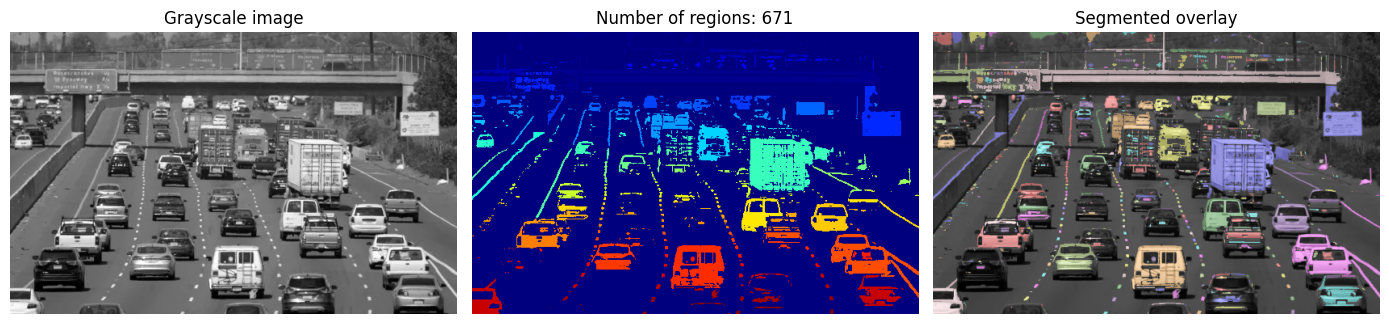

In [13]:
import matplotlib.pyplot as plt
import skimage as sk
from skimage import io
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from skimage.measure import label
from skimage.color import label2rgb
from google.colab import drive
drive.mount('/content/drive')
img = sk.io.imread("/content/drive/MyDrive/Colab Notebooks/cars.webp")
IG = rgb2gray(img)
thresh = threshold_otsu(IG)
binary_img = IG > thresh
label_image, nregions = label(binary_img, return_num=True)
image_label_overlay = label2rgb(label_image, image=IG, bg_label=0)
fig, axes = plt.subplots(1, 3, figsize=(14, 9))
ax = axes.ravel()
ax[0].imshow(IG, cmap='gray')
ax[0].set_title('Grayscale image')
ax[1].imshow(label_image, cmap='jet')
ax[1].set_title(f'Number of regions: {nregions}')
ax[2].imshow(image_label_overlay)
ax[2].set_title('Segmented overlay')
for a in ax:
    a.set_axis_off()
plt.tight_layout()
plt.show()

Now we have to obtain regional properties which means we have to calculate numerical features that describe each region.

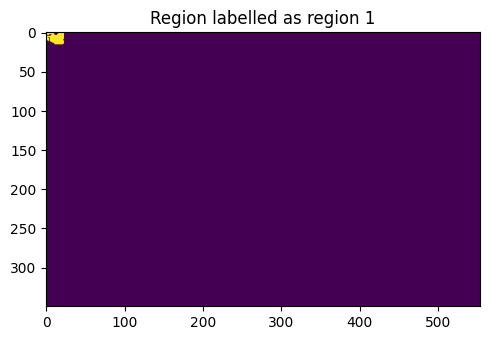

Area of Region 1: 310.0 pixels
Centroiod of Region 1: (np.float64(7.687096774193549), np.float64(11.890322580645162)) 
Eccentricity of Region 1: 0.7496304287154414
Major Axis Length of Region 1: 26.274635434446715 pixels
Minor Axis Length of Region 1: 17.390042093232513 pixels
Perimeter of Region 1: 107.698484809835 pixels
Orientation of Region 1: 1.2700990198961541 degrees


In [16]:
from skimage.measure import regionprops
import numpy as np
props = regionprops(label_image)
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(label_image==1)
ax.set_title('Region labelled as region 1') # set figure title
plt.tight_layout()
plt.show()
print('Area of Region 1: {} pixels'.format(props[0].area))
print('Centroiod of Region 1: {} '.format(props[0].centroid))
print('Eccentricity of Region 1: {}'.format(props[0].eccentricity))
print('Major Axis Length of Region 1: {} pixels'.format(props[0].major_axis_length))
print('Minor Axis Length of Region 1: {} pixels'.format(props[0].minor_axis_length))
print('Perimeter of Region 1: {} pixels'.format(props[0].perimeter))
print('Orientation of Region 1: {} degrees'.format(props[0].orientation))

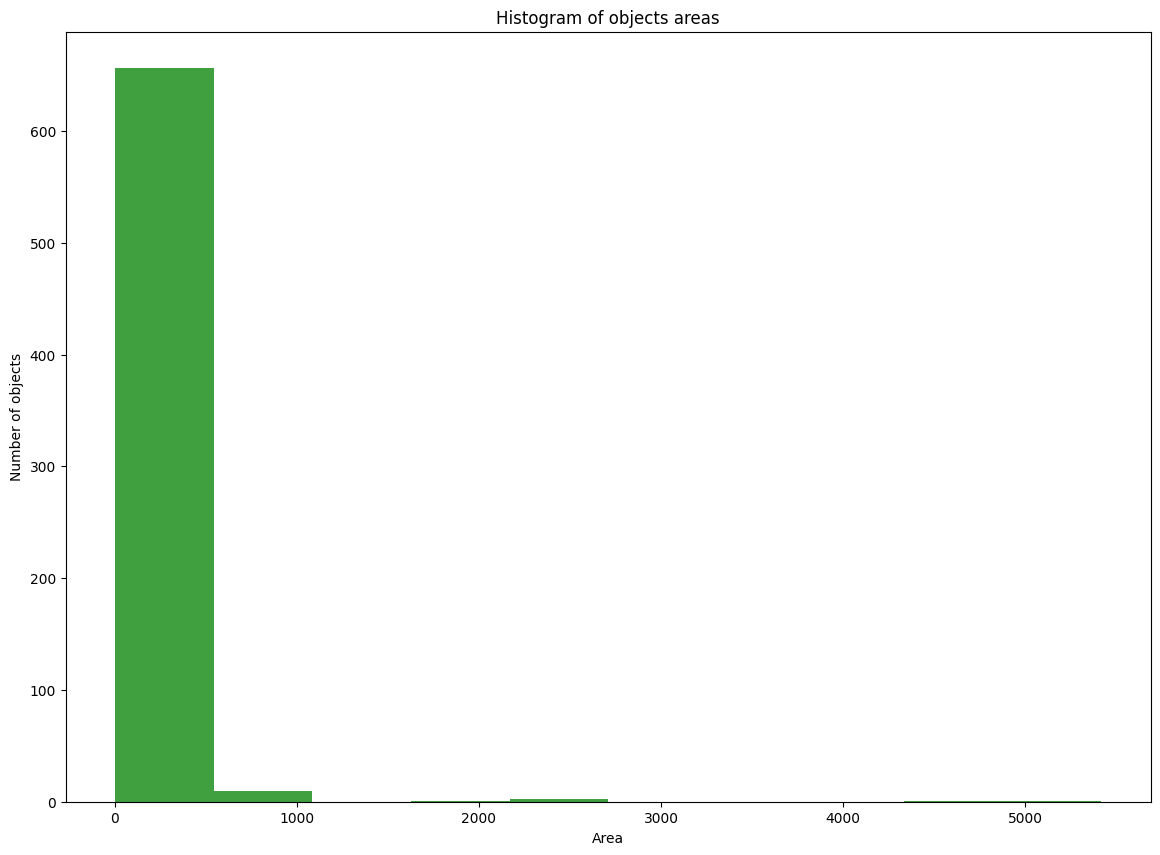

In [17]:
import numpy as np
area = np.zeros(nregions)
for i in range(0,nregions):
    area[i] = props[i].area
fig = plt.figure(figsize=(14, 10))
n, bins, patches = plt.hist(area, density=False, facecolor='g', alpha=0.75)
plt.xlabel('Area')
plt.ylabel('Number of objects')
plt.title('Histogram of objects areas')
plt.show()

In [18]:
ind_large = np.where(area > 3000)
ind_lregions = np.array(ind_large)+1
area_large = area[ind_large]
print('There are {} large objects'.format(len(area_large)))
print('Large objects correspond to regions: {}'.format(ind_lregions))
print('The areas of the large objects are: {}'.format(area_large))

ind_small = np.where(area < 3000)
area_small = area[ind_small]
ind_sregions = np.array(ind_small)+1
print('There are {} small objects'.format(len(area_small)))
print('Small objects correspond to regions: {}'.format(ind_sregions))
print('The areas of the small objects are {}'.format(area_small))

There are 2 large objects
Large objects correspond to regions: [[  9 282]]
The areas of the large objects are: [5418. 4570.]
There are 669 small objects
Small objects correspond to regions: [[  1   2   3   4   5   6   7   8  10  11  12  13  14  15  16  17  18  19
   20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37
   38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55
   56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73
   74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91
   92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108 109
  110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127
  128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145
  146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163
  164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181
  182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 

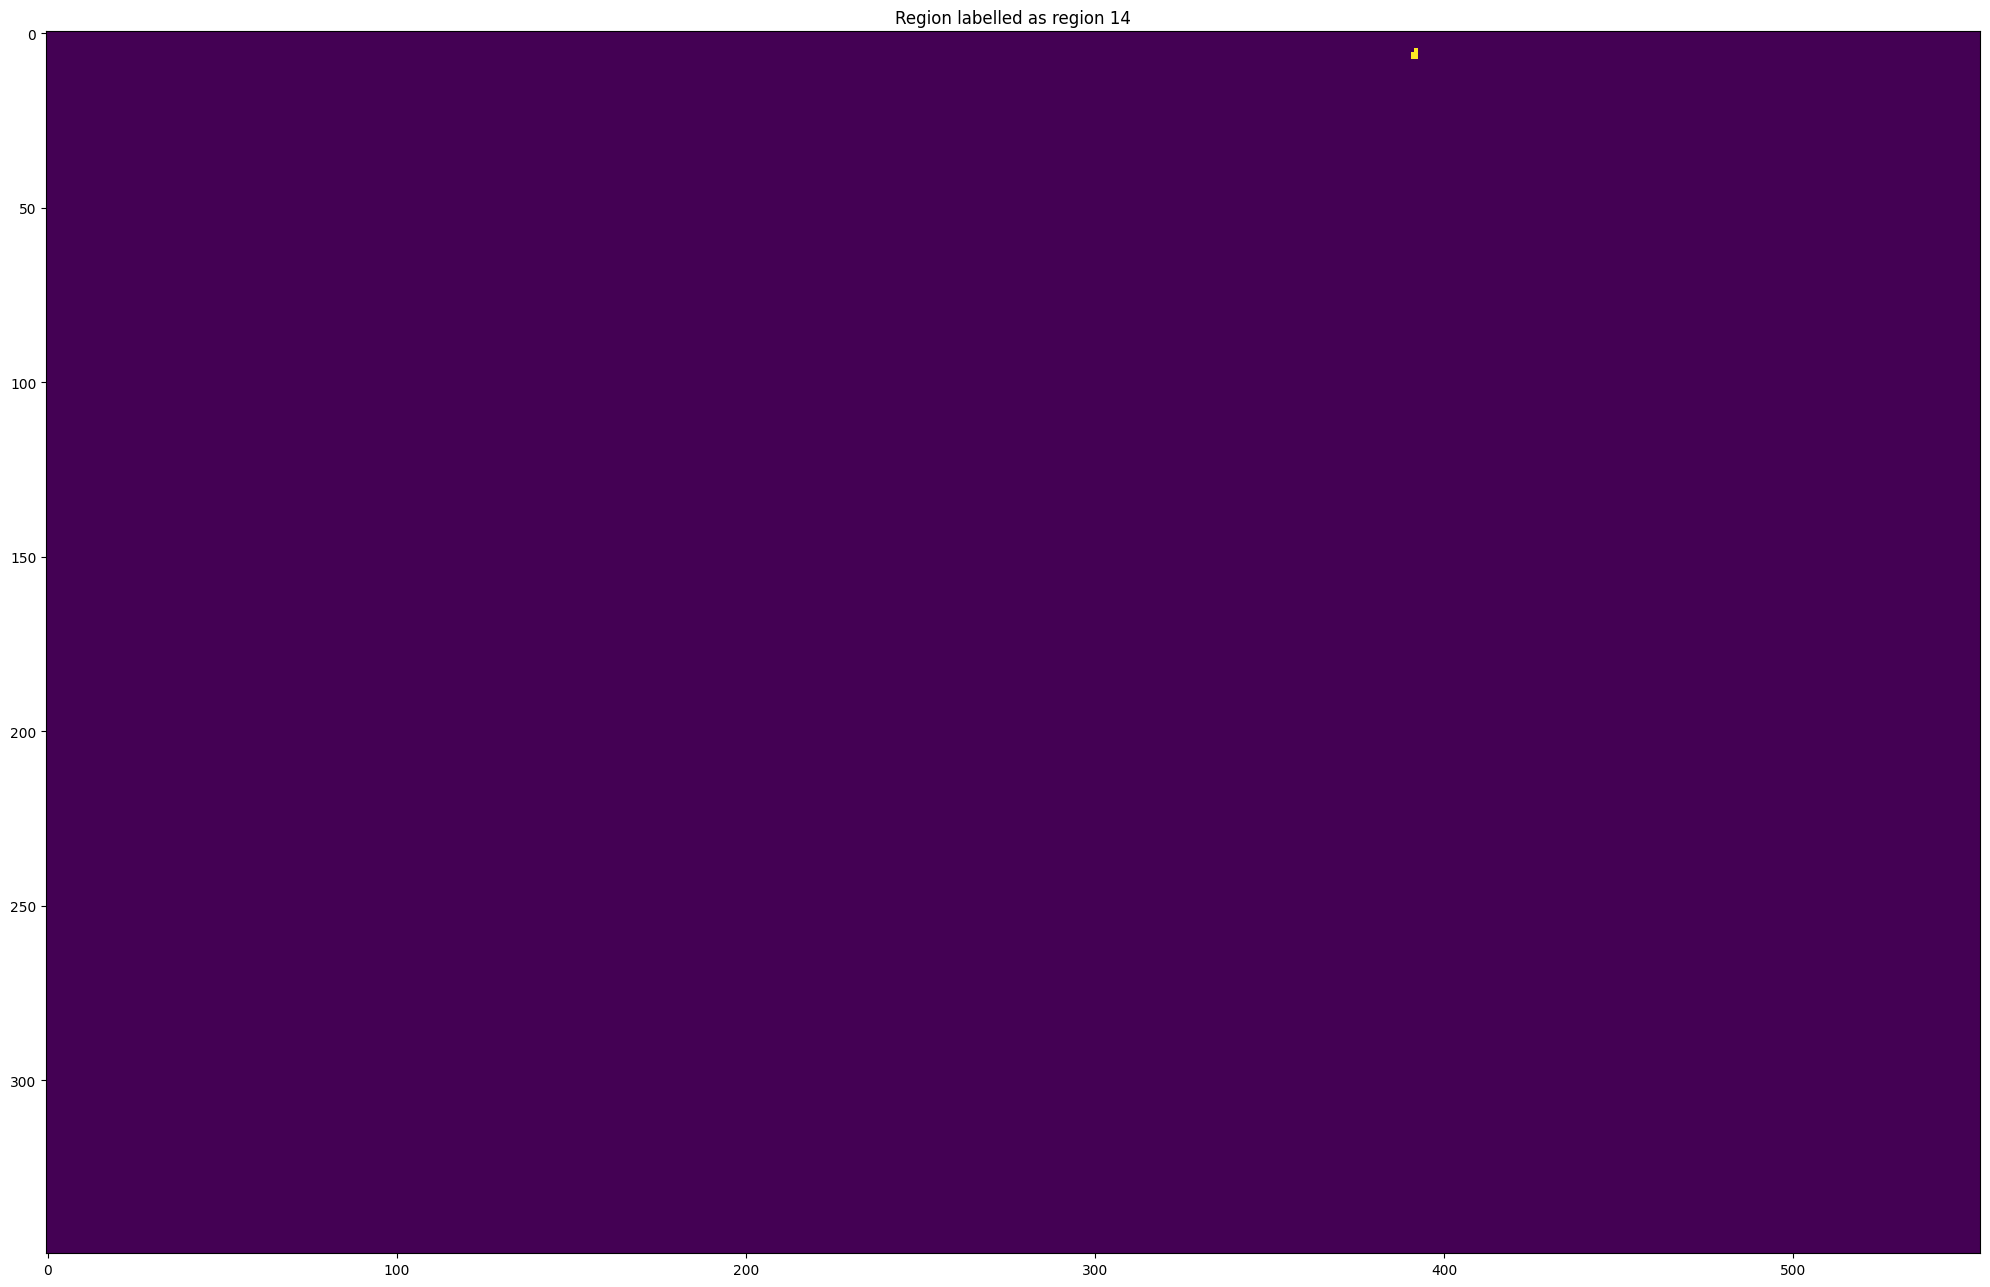

Area of Region 14: 5.0 pixels
Centroiod of Region 14: (np.float64(6.2), np.float64(391.6)) 
Eccentricity of Region 14: 0.816496580927726
Major Axis Length of Region 14: 3.098386676965933 pixels
Minor Axis Length of Region 14: 1.7888543819998317 pixels
Perimeter of Region 14: 5.207106781186548 pixels
Orientation of Region 14: -0.3217505543966422 degrees


In [19]:
fig, ax = plt.subplots(figsize=(20, 20))
ax.imshow(label_image==14)
ax.set_title('Region labelled as region 14') # set figure title
plt.tight_layout()
plt.show()

print('Area of Region 14: {} pixels'.format(props[13].area))
print('Centroiod of Region 14: {} '.format(props[13].centroid))
print('Eccentricity of Region 14: {}'.format(props[13].eccentricity))
print('Major Axis Length of Region 14: {} pixels'.format(props[13].major_axis_length))
print('Minor Axis Length of Region 14: {} pixels'.format(props[13].minor_axis_length))
print('Perimeter of Region 14: {} pixels'.format(props[13].perimeter))
print('Orientation of Region 14: {} degrees'.format(props[13].orientation))

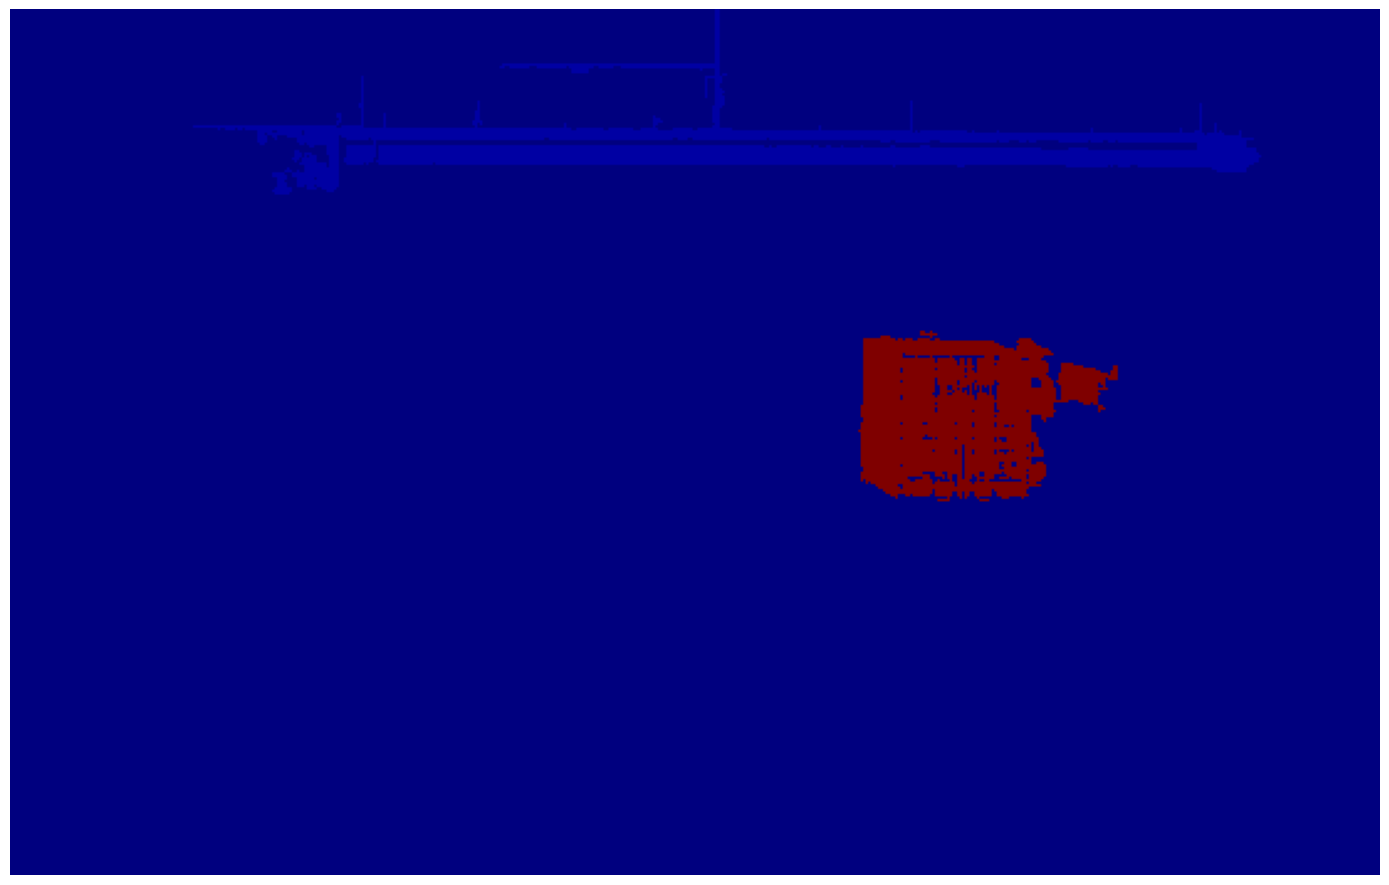

In [20]:
for i in np.squeeze(ind_small):
    iregion = i+1
    label_image[label_image==iregion]=0

image_label_overlay = label2rgb(label_image, image=IG)

fig, ax = plt.subplots(figsize=(14, 9))
ax.imshow(label_image,cmap=plt.cm.jet)
ax.set_axis_off()
plt.tight_layout()
plt.show()

The number of final regions is 2


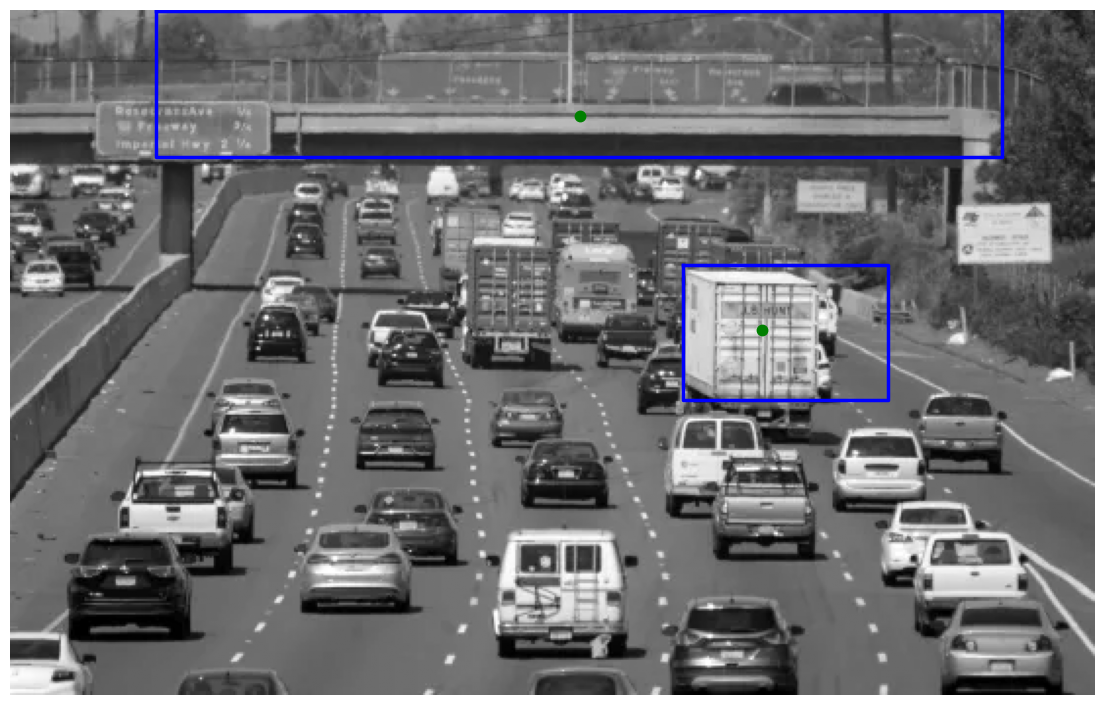

In [21]:
from skimage.measure import regionprops
import math

props = regionprops(label_image)
print('The number of final regions is {}'.format(len(props)))

fig, ax = plt.subplots(figsize=(14,10))
ax.imshow(IG, cmap=plt.cm.gray)

for p in props:
    y0, x0 = p.centroid
    ax.plot(x0, y0, '.g', markersize=15)

    minr, minc, maxr, maxc = p.bbox
    bx = (minc, maxc, maxc, minc, minc)
    by = (minr, minr, maxr, maxr, minr)
    ax.plot(bx, by, '-b', linewidth=2.5)

ax.set_axis_off()
plt.show()

Shannon’s entropy is a concept used to measure the amount of uncertainty or randomness in a dataset or image. It tells us how predictable or unpredictable the information is. If the data is very uniform and easy to predict, the entropy is low. If the data is varied and irregular, the entropy is high.
In computer vision, entropy is often calculated from pixel intensity values or from regions in a segmented image. A region with mostly similar pixel values, such as a plain wall or clear sky, will have low entropy because there is little variation. On the other hand, a region with many different pixel values, such as a forest or a noisy image, will have high entropy because it contains more complexity and variation.

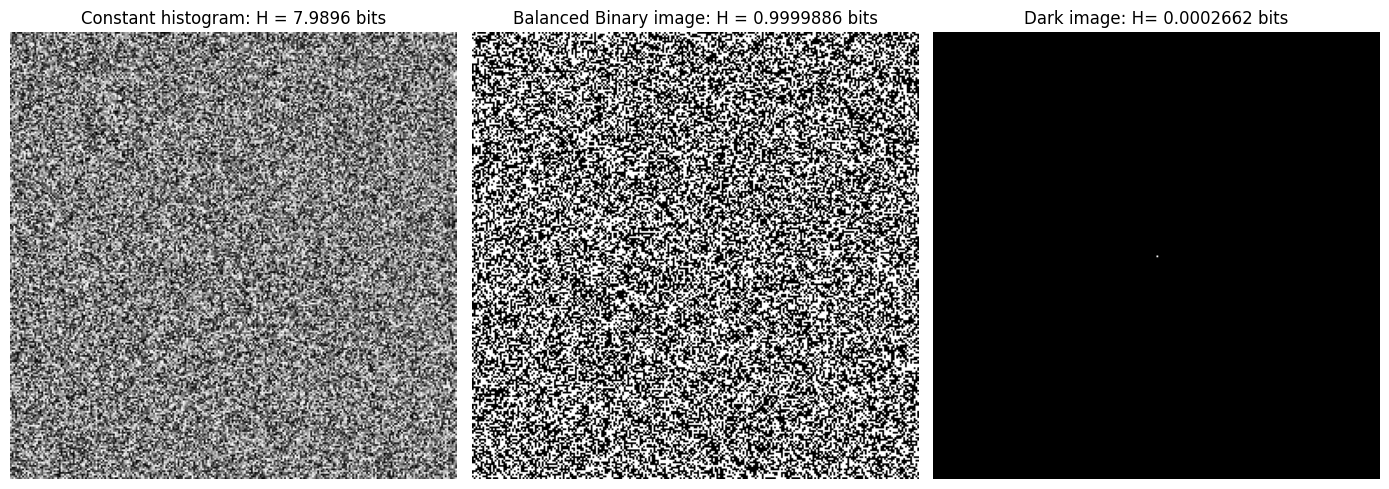

In [22]:
import matplotlib.pyplot as plt
import numpy as np
I1 = np.random.randint(256,size=(256,256))
v = I1.flatten()
probg,edges = np.histogram(v,bins=np.arange(256), density=True)
eps = 1e-16
probg = probg + eps
H1 = -np.sum(probg * np.log2(probg), axis=0)
I2 = np.random.randint(2,size=(256,256))
v = I2.flatten()
probg,edges = np.histogram(v,bins=np.arange(256), density=True)
eps = 1e-16
probg = probg + eps
H2 = -np.sum(probg * np.log2(probg), axis=0)
I3 = np.zeros((256,256))
I3[128,128]=1
v = I3.flatten()
probg,edges = np.histogram(v,bins=np.arange(256), density=True)
eps = 1e-16
probg = probg + eps
H3 = -np.sum(probg * np.log2(probg), axis=0)
fig, axes = plt.subplots(1,3,figsize=(14, 9))
ax = axes.ravel()
ax[0].imshow(I1,cmap=plt.cm.gray)
ax[0].set_title('Constant histogram: H = {0:1.4f} bits'.format(H1))
ax[1].imshow(I2,cmap=plt.cm.gray)
ax[1].set_title('Balanced Binary image: H = {0:1.7f} bits'.format(H2))
ax[2].imshow(I3,cmap=plt.cm.gray)
ax[2].set_title('Dark image: H= {0:1.7f} bits'.format(H3))
ax[0].set_axis_off()
ax[1].set_axis_off()
ax[2].set_axis_off()
plt.tight_layout()
plt.show()